# F3-matrices — Session 1: Matrices as Maps

*One class session, roughly 80 minutes. Prerequisite: F2-vectors (vectors,
norms, dot products, unit vectors, orthogonality) and, through it,
F1-scientific-python (broadcasting, axis aggregations, seeded randomness,
matplotlib).*

**This session:** the matrix as a machine that eats a vector and returns a
vector, a gallery of 2-D machines you can watch act (turns, stretches,
shears), the linearity contract that makes these machines special, the
column secret (a matrix is nothing but the list of where the basis goes),
and the exam's signature move — reconstructing a matrix from a description
of its action, by reading coefficients or by probing with basis vectors —
plus how to catch a described action that could not be linear at all.

Try every checkpoint by hand first, then verify with NumPy.
Answers are collected at the end of this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. A Machine That Eats Vectors

**Motivation.**
In F2 a vector was a *thing*: an arrow, a row of numbers, a data record.
This unit is about *machines that transform vectors*: rotate every point
of a drawing, convert a (grams, liters, count) record into (cost, mass)
totals, re-mix stereo channels into new channels.
The machines we study first are the best-behaved ones — and each such
machine is stored as a grid of numbers called a matrix.

**Definition.**
A **matrix** $M$ of shape $(n, k)$ is a rectangular grid of numbers with
$n$ rows and $k$ columns; $M_{ij}$ is the entry in row $i$, column $j$
(indices from 0, as in NumPy).
Its **action** on a vector $x$ with $k$ entries produces a vector
$y = Mx$ with $n$ entries, one dot product per output entry:
$$y_i \;=\; (\text{row } i \text{ of } M) \cdot x \;=\; \sum_{j=0}^{k-1} M_{ij}\, x_j .$$
Picture it as a box: a length-$k$ vector goes in, a length-$n$ vector
comes out.
The matrix is the machine's wiring diagram — entry $M_{ij}$ says how
strongly input slot $j$ feeds output slot $i$.

**Worked example (square).**
$M = \begin{pmatrix} 1 & 2 \\ 3 & -1 \end{pmatrix}$ acting on $x = (2, 1)$:
$$y_0 = 1 \cdot 2 + 2 \cdot 1 = 4, \qquad y_1 = 3 \cdot 2 + (-1) \cdot 1 = 5,$$
so $Mx = (4, 5)$.

**Worked example (rectangular).**
$A = \begin{pmatrix} 1 & 0 & 2 \\ 0 & 1 & -1 \end{pmatrix}$ has shape
$(2, 3)$: it eats length-3 vectors and emits length-2 vectors.
On $x = (1, 1, 1)$: $y_0 = 1 + 0 + 2 = 3$ and $y_1 = 0 + 1 - 1 = 0$,
so $Ax = (3, 0)$.
A non-square matrix *changes the dimension* of its input.

**In code, straight from the definition.**
The formula "each output entry is a row of $M$ dotted with $x$" is one
broadcasting idiom away: `M * x` scales each column of `M` by the
matching entry of `x` (shapes $(n, k) \times (k,) \to (n, k)$), and
summing across each row (`axis=1`) finishes the dot products.
NumPy also has a dedicated product operator — that is Session 2's
business; today we compute actions straight from the definition.

In [2]:
def apply_map(M, x):
    # y_i = sum_j M_ij x_j : scale the columns by x, then sum along each row.
    return (M * x).sum(axis=1)


M = np.array([[1., 2.], [3., -1.]])
A = np.array([[1., 0., 2.], [0., 1., -1.]])

print("M applied to (2, 1)    :", apply_map(M, np.array([2., 1.])))      # (4, 5)
print("A applied to (1, 1, 1) :", apply_map(A, np.array([1., 1., 1.])))  # (3, 0)
print("shapes: M", M.shape, "eats length 2, emits length 2;",
      "A", A.shape, "eats length 3, emits length 2")

M applied to (2, 1)    : [4. 5.]
A applied to (1, 1, 1) : [3. 0.]
shapes: M (2, 2) eats length 2, emits length 2; A (2, 3) eats length 3, emits length 2


### Checkpoint 1

1. By hand: apply $B = \begin{pmatrix} 2 & -1 \\ 1 & 3 \end{pmatrix}$ to
   $x = (1, 2)$ and to $y = (3, -1)$.
2. A matrix has shape $(3, 4)$.
   What input length does it eat, what output length does it emit, and
   can it act on a vector of shape `(3,)`?
3. In `apply_map`, what is the shape of the intermediate `M * x` for
   `M` of shape `(3, 4)` — and what does each of its entries mean?

## 2. A Gallery of 2-D Machines

**Motivation.**
For $2 \times 2$ matrices you can *watch* the machine work: feed it every
corner of a drawing and plot what comes out.
Three machines cover most of the geometric vocabulary you will need.

**The cast.**

- **Rotation** by angle $\theta$:
  $R = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$ —
  turns every vector by $\theta$ counterclockwise, lengths untouched.
- **Stretch** (axis scaling):
  $D = \begin{pmatrix} 2 & 0 \\ 0 & \tfrac12 \end{pmatrix}$ —
  doubles the horizontal, halves the vertical.
- **Shear**:
  $S = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}$ —
  slides each point horizontally by its own height; the ground floor
  ($x_1 = 0$) does not move.

**Applying one machine to many points at once.**
Stack the points as the *rows* of an array `pts` of shape $(p, 2)$.
Broadcasting runs all the dot products in one expression:
`pts[:, None, :]` has shape $(p, 1, 2)$, `M[None, :, :]` has shape
$(1, 2, 2)$; their product is a $(p, 2, 2)$ block whose $[q, i, j]$
entry is $M_{ij}\, x_j$ for point $q$, and summing over `axis=2`
collapses the $j$ index — one dot product per point per output entry,
result shape $(p, 2)$.
(This idiom returns with bans attached in the practice set; make friends
with it now.)

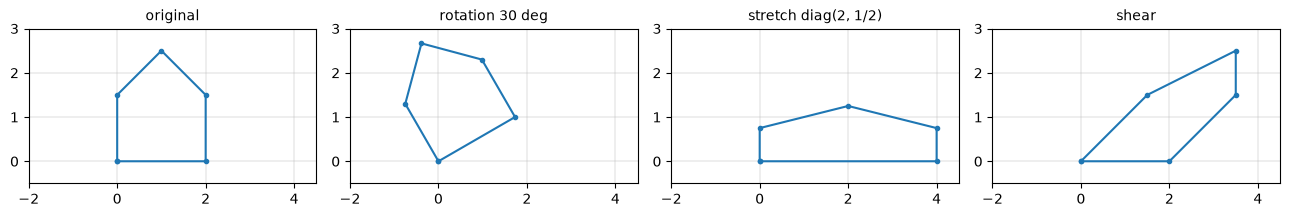

In [3]:
def apply_points(M, pts):
    # rows of pts are points; returns the mapped points as rows.
    return (M[None, :, :] * pts[:, None, :]).sum(axis=2)


theta = np.pi / 6                                # 30 degrees
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
D = np.array([[2.0, 0.0], [0.0, 0.5]])           # stretch
S = np.array([[1.0, 1.0], [0.0, 1.0]])           # shear

# A small house outline (closed polygon), one point per row.
house = np.array([[0., 0.], [2., 0.], [2., 1.5], [1., 2.5],
                  [0., 1.5], [0., 0.]])

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
panels = [("original", house),
          ("rotation 30 deg", apply_points(R, house)),
          ("stretch diag(2, 1/2)", apply_points(D, house)),
          ("shear", apply_points(S, house))]
for ax, (name, mapped) in zip(axes, panels):
    ax.plot(mapped[:, 0], mapped[:, 1], marker="o", markersize=3)
    ax.set_title(name, fontsize=10)
    ax.set_aspect("equal")
    ax.grid(True, linewidth=0.3)
    ax.set_xlim(-2, 4.5)
    ax.set_ylim(-0.5, 3)
plt.tight_layout()
plt.show()

In [4]:
# Rotation preserves lengths; the others generally do not.
corner = np.array([2., 1.5])
for name, M_ in [("rotation", R), ("stretch", D), ("shear", S)]:
    out = apply_map(M_, corner)
    print(f"{name:9s}: |x| = {np.sqrt((corner**2).sum()):.4f}  ->  "
          f"|Mx| = {np.sqrt((out**2).sum()):.4f}")

rotation : |x| = 2.5000  ->  |Mx| = 2.5000
stretch  : |x| = 2.5000  ->  |Mx| = 4.0697
shear    : |x| = 2.5000  ->  |Mx| = 3.8079


### Checkpoint 2

1. By hand: where does the shear $S$ send $(1, 1)$? And $(1, 0)$?
2. The stretch $\mathrm{diag}(3, 1)$ sends $(x_0, x_1)$ to
   $(3x_0, x_1)$.
   Which points does it leave exactly where they were?
3. One of the three gallery machines never changes any vector's length.
   Which one — and give a vector whose length the shear *does* change.

## 3. The Linearity Contract

**Motivation.**
Not every vector-to-vector function deserves a matrix.
What makes matrix machines special is a two-clause contract, and that
contract — not the grid of numbers — is the real heart of the subject.

**Definition.**
A function $f$ from length-$k$ vectors to length-$n$ vectors is
**linear** when, for all vectors $x, y$ and every scalar $c$:
$$f(c\,x) = c\, f(x) \qquad\text{(scaling respected)},$$
$$f(x + y) = f(x) + f(y) \qquad\text{(addition respected)}.$$
The two clauses combine into one master rule:
$f(a\,x + b\,y) = a\,f(x) + b\,f(y)$ — the image of a combination is
the same combination of the images.

**Every matrix action honors the contract.**
Check clause 2 on entry $i$ (clause 1 is the same one-liner):
$$\big(M(x + y)\big)_i = \sum_j M_{ij}(x_j + y_j)
  = \sum_j M_{ij}x_j + \sum_j M_{ij}y_j = (Mx)_i + (My)_i .$$
Sums distribute — that is the whole proof.
The converse is also true and is Section 4's punchline: every function
honoring the contract *is* a matrix action.

**Two immediate consequences.**

- **Zero to zero:** $f(0) = f(0 \cdot 0) = 0 \cdot f(0) = 0$.
  Any machine that moves the origin has already broken the contract.
- **Few values determine many:** if you know $f(u)$ and $f(v)$, you know
  $f$ on *every* combination $a\,u + b\,v$ — no further measurements
  needed.
  This consequence powers everything in Sections 5–7.

**Non-examples.**
The shift $g(x) = (x_0 + 1,\; x_1)$ moves the origin: not linear.
The squarer $h(x) = (x_0^2,\; x_1)$ breaks scaling:
$h(2x) \ne 2\,h(x)$ as soon as $x_0 \ne 0$.

In [5]:
SEED = 20260804
rng = np.random.default_rng(SEED)
x, y = rng.normal(0, 1, (2, 2))
a, b = 2.0, -3.0

lhs = apply_map(M, a * x + b * y)
rhs = a * apply_map(M, x) + b * apply_map(M, y)
print("M(ax + by) :", lhs)
print("a Mx + b My:", rhs)
print("contract gap:", np.abs(lhs - rhs).max())   # ~0: the action is linear


def shift(v):     # moves the origin
    return np.array([v[0] + 1.0, v[1]])


def squarer(v):   # breaks scaling
    return np.array([v[0] ** 2, v[1]])


print("shift(0):", shift(np.zeros(2)), " <- a linear map must give [0. 0.]")
print("squarer(2x) - 2*squarer(x):", squarer(2 * x) - 2 * squarer(x))

M(ax + by) : [-4.26214857 -2.75609775]
a Mx + b My: [-4.26214857 -2.75609775]
contract gap: 4.440892098500626e-16
shift(0): [1. 0.]  <- a linear map must give [0. 0.]
squarer(2x) - 2*squarer(x): [0.65482009 0.        ]


### Checkpoint 3

1. Show by a concrete evaluation that $f(x) = (x_0 + 1,\; x_1)$ is not
   linear.
2. A linear map $f$ satisfies $f(u) = (2, 0)$ and $f(v) = (1, 1)$.
   Compute $f(3u - v)$.
3. One line: why must *every* linear map send the zero vector to the
   zero vector?

## 4. Columns Are Where the Basis Goes

**Motivation.**
Section 1 read a matrix row-wise: one dot product per output entry.
There is a second reading, column-wise, and it is the one the exam's
favorite problems are built on.

**The standard basis.**
$e_j$ is the vector with a 1 in slot $j$ and 0 elsewhere; in
$\mathbb{R}^3$: $e_0 = (1,0,0)$, $e_1 = (0,1,0)$, $e_2 = (0,0,1)$.
Every vector is a combination of them:
$x = x_0 e_0 + x_1 e_1 + \cdots + x_{k-1} e_{k-1}$.

**The column secret.**
Feed $e_j$ into the machine: in $\sum_t M_{it}\,(e_j)_t$ only the
$t = j$ term survives, so
$$M e_j = \text{column } j \text{ of } M .$$
A matrix is *literally the list of the basis images*, stacked side by
side.
Combined with the linearity contract:
$$Mx = M\Big(\sum_j x_j e_j\Big) = \sum_j x_j\, (M e_j)
    = \sum_j x_j \cdot (\text{column } j).$$
**The output is a combination of the columns, weighted by the input's
entries.**

**Worked example.**
$A = \begin{pmatrix} 1 & 0 & 2 \\ 0 & 1 & -1 \end{pmatrix}$ from
Section 1, on $x = (1, 1, 1)$, column-wise:
$$Ax = 1 \cdot \binom{1}{0} + 1 \cdot \binom{0}{1} + 1 \cdot \binom{2}{-1}
     = \binom{3}{0},$$
matching the row-wise answer.
Two readings, one machine: rows tell you *how each output entry is
assembled*; columns tell you *where the input's building blocks land*.

In [6]:
d = A.shape[1]
for j in range(d):
    e_j = np.eye(d)[j]
    print(f"A e_{j} = {apply_map(A, e_j)}   column {j} of A = {A[:, j]}")

x = np.array([1., 1., 1.])
print("column combination:", x[0] * A[:, 0] + x[1] * A[:, 1] + x[2] * A[:, 2])
print("apply_map         :", apply_map(A, x))

A e_0 = [1. 0.]   column 0 of A = [1. 0.]
A e_1 = [0. 1.]   column 1 of A = [0. 1.]
A e_2 = [ 2. -1.]   column 2 of A = [ 2. -1.]
column combination: [3. 0.]
apply_map         : [3. 0.]


### Checkpoint 4

1. A linear map on $\mathbb{R}^2$ sends $e_0 \mapsto (4, 1)$ and
   $e_1 \mapsto (-2, 3)$.
   Write its matrix.
2. For that matrix and $x = (2, 5)$, write $Mx$ as a weighted
   combination of columns and evaluate it.
3. A machine on $\mathbb{R}^3$ sends $e_1$ to the zero vector.
   What does that force about its matrix?

## 5. Reading the Matrix Off a Formula

**Motivation.**
The exam's signature pattern hands you a map as a *formula* — "the map
sends $x$ to (some expressions in the $x_j$)" — and asks for the matrix.
No probing needed: the coefficients are sitting in plain sight, provided
you file them into the right slots.

**The method.**
Output entry $i$'s formula *is* row $i$ of the matrix:
the coefficient of $x_j$ in that formula is exactly $M_{ij}$.
A variable that never appears has coefficient $0$ — write the zero, in
its column, every time.

**Worked example A (square).**
$f(x) = (3x_0 - x_1,\;\; x_0 + 2x_1)$ on $\mathbb{R}^2$.
Row 0 reads off $(3, -1)$; row 1 reads off $(1, 2)$:
$$F = \begin{pmatrix} 3 & -1 \\ 1 & 2 \end{pmatrix}.$$

**Worked example B (a silent variable).**
$g(x) = (2x_0 + x_2,\;\; 5x_2)$ eats $\mathbb{R}^3$ vectors and emits
$\mathbb{R}^2$ vectors, so its matrix is $(2, 3)$ — *three* columns even
though only two variables show up.
$x_1$ appears nowhere: its column is all zeros.
$$G = \begin{pmatrix} 2 & 0 & 1 \\ 0 & 0 & 5 \end{pmatrix}.$$
Forgetting that middle column (writing a $2 \times 2$ matrix) is a
classic blunder — Section 8 dissects it.

**Worked example C (more outputs than inputs).**
$h(x) = (x_1,\;\; 4x_0 - 5x_1,\;\; 2x_0)$ maps
$\mathbb{R}^2 \to \mathbb{R}^3$:
$$H = \begin{pmatrix} 0 & 1 \\ 4 & -5 \\ 2 & 0 \end{pmatrix}.$$
Shape check before anything else: (number of outputs, number of inputs)
$= (3, 2)$. ✓

The code below rebuilds all three and cross-checks each against its
formula on seeded random inputs — the habit that catches filing errors
instantly.

In [7]:
F = np.array([[3., -1.], [1., 2.]])
G = np.array([[2., 0., 1.], [0., 0., 5.]])
H = np.array([[0., 1.], [4., -5.], [2., 0.]])


def f_formula(v):
    return np.array([3 * v[0] - v[1], v[0] + 2 * v[1]])


def g_formula(v):
    return np.array([2 * v[0] + v[2], 5 * v[2]])


def h_formula(v):
    return np.array([v[1], 4 * v[0] - 5 * v[1], 2 * v[0]])


rng = np.random.default_rng(SEED)
for name, mat, formula in [("F", F, f_formula), ("G", G, g_formula),
                           ("H", H, h_formula)]:
    v = rng.normal(0, 1, mat.shape[1])
    gap = np.abs(apply_map(mat, v) - formula(v)).max()
    print(f"{name}: shape {mat.shape}, formula-vs-matrix gap on a random input: {gap:.2e}")

F: shape (2, 2), formula-vs-matrix gap on a random input: 0.00e+00
G: shape (2, 3), formula-vs-matrix gap on a random input: 0.00e+00
H: shape (3, 2), formula-vs-matrix gap on a random input: 0.00e+00


### Checkpoint 5

1. Reconstruct the matrix of $f(x) = (x_2 - x_0,\;\; 3x_1)$ on
   $\mathbb{R}^3$ (mind the zeros).
2. Reconstruct the matrix of $f(x) = (5x_1,\;\; x_0 + x_1,\;\; -x_0)$ on
   $\mathbb{R}^2$.
3. A formula takes 4 input variables to 2 output expressions.
   What is the matrix's shape, before you read a single coefficient?

## 6. Probing a Mystery Machine

**Motivation.**
Sometimes the map is not a formula but a *black box* — a library
function, a compiled routine, a colleague's code.
If the box is linear, Section 4 hands you a complete X-ray procedure:
feed it the basis vectors, and the outputs are the matrix's columns.
$k$ probes fully determine a map on $\mathbb{R}^k$ — this is the other
half of the exam's matrix-from-action pattern.

**The procedure.**

1. For $j = 0, \dots, k-1$: compute $c_j = \texttt{box}(e_j)$.
2. Assemble the $c_j$ as columns: $M = [\,c_0 \;|\; c_1 \;|\; \cdots\,]$.
3. Cross-check on a fresh random vector: $\texttt{box}(v)$ must equal
   $Mv$.

Step 3 is not decoration.
Probing *records* the basis images; only linearity guarantees those
images determine the rest.
If the box is secretly nonlinear, steps 1–2 still produce a matrix — a
matrix that *lies* everywhere except on the probes themselves.

In [8]:
def box(v):
    # Today's mystery machine (pretend you cannot read this).
    return np.array([v[2] - v[0], v[0] + v[1] + v[2], 2 * v[1]])


k = 3
probes = np.eye(k)
columns = [box(probes[j]) for j in range(k)]   # a loop over probes is the
M_recovered = np.stack(columns, axis=1)        # bookkeeping, not the math
print("recovered matrix:")
print(M_recovered)

v = np.random.default_rng(SEED).normal(0, 1, k)
gap = np.abs(box(v) - apply_map(M_recovered, v)).max()
print("cross-check gap on a fresh vector:", gap)   # ~0: the box behaves linearly

recovered matrix:
[[-1.  0.  1.]
 [ 1.  1.  1.]
 [ 0.  2.  0.]]
cross-check gap on a fresh vector: 0.0


In [9]:
def sneaky(v):
    # NOT linear -- but it agrees with the identity map on both probes.
    return np.array([v[0] ** 2, v[1]])


probes2 = np.eye(2)
M_lie = np.stack([sneaky(probes2[j]) for j in range(2)], axis=1)
print("probed 'matrix':")
print(M_lie)                                        # looks like the identity
test = np.array([2., 0.])
print("sneaky((2, 0)) :", sneaky(test))             # (4, 0)
print("matrix predicts:", apply_map(M_lie, test))   # (2, 0) -- the matrix lies

probed 'matrix':
[[1. 0.]
 [0. 1.]]
sneaky((2, 0)) : [4. 0.]
matrix predicts: [2. 0.]


### Checkpoint 6

1. How many probes fully determine a linear map from $\mathbb{R}^5$ to
   $\mathbb{R}^2$, and what shape is each probe's output?
2. Probing a linear box on $\mathbb{R}^3$ gives
   $\texttt{box}(e_0) = (1, 2)$, $\texttt{box}(e_1) = (0, 1)$,
   $\texttt{box}(e_2) = (2, 0)$.
   Write the matrix, then compute $\texttt{box}((1, 1, 1))$ without
   calling the box.
3. Why does probing a *nonlinear* machine produce a matrix that "lies",
   and on which inputs is that matrix still guaranteed to be right?

## 7. Could This Even Be Linear?

**Motivation.**
A vendor documents an image filter only through examples:
"$(1,0) \mapsto \dots$, $(0,1) \mapsto \dots$, $(3,2) \mapsto \dots$".
Before you reconstruct a matrix from such a datasheet, ask the sharper
question: *is the documented behavior even consistent with linearity?*
The contract makes documented examples talk to each other — and
sometimes they contradict.

**The consistency check.**
Express one documented input as a combination of the others; linearity
then *predicts* its output as the same combination of their outputs.
Compare prediction with documentation:

- **Match** → consistent so far; reconstruct the matrix from the basis
  examples.
- **Mismatch** → no linear map can produce this datasheet, full stop.

**Worked example A (consistent).**
Filter-A: $(1,0) \mapsto (0,2)$, $(0,1) \mapsto (1,0)$,
$(2,3) \mapsto (3,4)$.
Since $(2,3) = 2\,e_0 + 3\,e_1$, linearity predicts
$2\,(0,2) + 3\,(1,0) = (3,4)$ — exactly what is documented. ✓
Matrix from the basis examples (columns!):
$\begin{pmatrix} 0 & 1 \\ 2 & 0 \end{pmatrix}$.

**Worked example B (inconsistent).**
Filter-B: $(1,0) \mapsto (1,1)$, $(0,1) \mapsto (2,0)$,
$(1,2) \mapsto (4,1)$.
Prediction for $(1,2) = e_0 + 2\,e_1$: $(1,1) + 2\,(2,0) = (5,1)$.
Documented: $(4,1)$.
Mismatch → Filter-B is not linear (or its datasheet is wrong); writing
down "its matrix" would be meaningless.

**Worked example C (scaling alone can refute).**
Filter-C: $(1,0) \mapsto (0,1)$ and $(2,0) \mapsto (2,2)$.
But $(2,0) = 2\,(1,0)$, so linearity demands the output
$2\,(0,1) = (0,2) \ne (2,2)$. ✗

**What a passed check does — and does not — prove.**
Each verified example refutes or *fails to refute*; finitely many
consistent examples never prove linearity (the sneaky box of Section 6
passed every probe).
On the exam, "check the extra documented example against the first two"
is exactly the intended work — state the combination, the prediction,
and the verdict.

In [10]:
docs_A = {(1, 0): (0, 2), (0, 1): (1, 0), (2, 3): (3, 4)}
docs_B = {(1, 0): (1, 1), (0, 1): (2, 0), (1, 2): (4, 1)}

for name, docs in [("Filter-A", docs_A), ("Filter-B", docs_B)]:
    out_e0 = np.array(docs[(1, 0)], dtype=float)
    out_e1 = np.array(docs[(0, 1)], dtype=float)
    extras = [(i, o) for i, o in docs.items() if i not in [(1, 0), (0, 1)]]
    (extra_in, extra_out), = extras
    a, b = extra_in
    predicted = a * out_e0 + b * out_e1
    documented = np.array(extra_out, dtype=float)
    verdict = "consistent" if np.allclose(predicted, documented, atol=0, rtol=0) else "NOT linear"
    print(f"{name}: {extra_in} predicted -> {predicted}, "
          f"documented -> {documented}  [{verdict}]")

Filter-A: (2, 3) predicted -> [3. 4.], documented -> [3. 4.]  [consistent]
Filter-B: (1, 2) predicted -> [5. 1.], documented -> [4. 1.]  [NOT linear]


### Checkpoint 7

1. Datasheet: $(1,0) \mapsto (2,1)$, $(0,1) \mapsto (0,3)$,
   $(1,1) \mapsto (2,4)$.
   Consistent with linearity?
   Show the prediction.
2. Datasheet: $(1,0) \mapsto (0,1)$, $(2,0) \mapsto (2,2)$.
   Consistent?
   One line.
3. A datasheet's every example checks out.
   Why is "this filter is linear" still not *proved*?

## 8. Common Pitfalls I

**Pitfall 1 — filing coefficients into the wrong slots.**
Asked for the matrix of $f(x) = (x_0 - 7x_1,\;\; 2x_1)$, a student files
each *output's* coefficients down a *column* and writes
$\begin{pmatrix} 1 & 2 \\ -7 & 0 \end{pmatrix}$.
The rule is row-wise: output entry $i$'s formula is **row** $i$.
The one-probe test exposes the error immediately — feed $e_0$ and
compare with the formula:

In [11]:
def f_target(v):
    return np.array([v[0] - 7 * v[1], 2 * v[1]])


M_broken = np.array([[1., 2.], [-7., 0.]])   # BROKEN: coefficients filed down columns
M_fixed = np.array([[1., -7.], [0., 2.]])    # row i = output i's coefficients

e0 = np.array([1., 0.])
print("formula on e0      :", f_target(e0))             # (1, 0)
print("broken matrix on e0:", apply_map(M_broken, e0))  # (1, -7) -- caught
print("fixed matrix on e0 :", apply_map(M_fixed, e0))   # (1, 0)  -- agrees

formula on e0      : [1. 0.]
broken matrix on e0: [ 1. -7.]
fixed matrix on e0 : [1. 0.]


The broken matrix has its rows and columns interchanged relative to the
right one — every prediction made with it silently answers a different
question.
Habit: after reconstructing, always probe with one basis vector and
compare against the formula.

**Pitfall 2 — the forgotten zero column.**
$g(x) = (2x_0 + x_2,\;\; 5x_2)$ mentions two variables, so a hurried
reader writes the $2 \times 2$ matrix
$\begin{pmatrix} 2 & 1 \\ 0 & 5 \end{pmatrix}$.
But the map eats $\mathbb{R}^3$: the matrix must have *three* columns,
and $x_1$'s silence means a zero column, not a missing one.
The bug is not subtle at run time — shapes refuse to line up:

In [12]:
G_broken = np.array([[2., 1.], [0., 5.]])        # BROKEN: dropped the silent x1 column
G_fixed = np.array([[2., 0., 1.], [0., 0., 5.]])

x3 = np.array([1., 4., 2.])                      # a legitimate length-3 input
print("g formula:", np.array([2 * x3[0] + x3[2], 5 * x3[2]]))
print("fixed    :", apply_map(G_fixed, x3))
try:
    apply_map(G_broken, x3)
except ValueError as err:
    print("broken   : ValueError --", err)

g formula: [ 4. 10.]
fixed    : [ 4. 10.]
broken   : ValueError -- operands could not be broadcast together with shapes (2,2) (3,) 


Count columns *from the input dimension*, never from how many variables
the formulas happen to mention.
(On paper the broken matrix does not even crash — it just answers a
different, two-input question.)

**Pitfall 3 — trusting a datasheet to be linear.**
Two documented examples always *fit* some matrix; that does not make the
machine linear.
Below, a machine with a hidden clamp agrees with a matrix on both basis
probes, then betrays the reconstruction on an everyday input.
Reconstruct-then-predict is only licensed once linearity is given (or
consistency-checked as in Section 7 — and even then, held as "consistent
so far", not proved):

In [13]:
def clamped(v):
    # hidden nonlinearity: output 0 saturates at 1.5
    return np.array([min(v[0] + v[1], 1.5), v[1]])


M_naive = np.stack([clamped(np.eye(2)[j]) for j in range(2)], axis=1)
print("matrix fit to the probes:")
print(M_naive)                                      # both probes fit perfectly

everyday = np.array([2., 1.])
print("machine on (2, 1):", clamped(everyday))            # clamp engages: (1.5, 1)
print("matrix predicts  :", apply_map(M_naive, everyday))  # (3, 1) -- wrong

matrix fit to the probes:
[[1. 1.]
 [0. 1.]]
machine on (2, 1): [1.5 1. ]
matrix predicts  : [3. 1.]


### Checkpoint 8

1. For $f(x) = (4x_1,\;\; x_0 - x_1)$ a classmate writes
   $\begin{pmatrix} 4 & 1 \\ 0 & -1 \end{pmatrix}$.
   Which pitfall is this, what is the correct matrix, and which single
   probe exposes the error?
2. A datasheet documents three input–output pairs for a photo filter and
   they pass the Section 7 consistency check.
   Name two distinct reasons you should still hesitate to call the
   reconstruction "the filter's matrix".

## Checkpoint Answers

<details><summary><b>Checkpoint 1</b></summary>

1. $Bx = (2 \cdot 1 - 1 \cdot 2,\; 1 \cdot 1 + 3 \cdot 2) = (0, 7)$;
   $\;By = (2 \cdot 3 - 1 \cdot (-1),\; 1 \cdot 3 + 3 \cdot (-1)) = (7, 0)$.
2. It eats length-4 vectors and emits length-3 vectors; it cannot act on
   a shape-`(3,)` vector (each row's dot product needs 4 entries).
3. `(M * x)` has shape `(3, 4)`: entry $[i, j]$ is the single product
   $M_{ij} x_j$ — the terms of the dot products, laid out before the
   row-sums collapse them.

</details>

<details><summary><b>Checkpoint 2</b></summary>

1. $S(1,1) = (1 \cdot 1 + 1 \cdot 1,\; 0 + 1) = (2, 1)$;
   $\;S(1,0) = (1, 0)$ — ground-floor points do not move.
2. $(3x_0, x_1) = (x_0, x_1)$ forces $x_0 = 0$: exactly the vertical
   axis is left in place.
3. The rotation (its rows are orthogonal unit vectors — F2's length
   preservation).
   The shear changes e.g. $(0, 1) \mapsto (1, 1)$: length
   $1 \to \sqrt{2}$.

</details>

<details><summary><b>Checkpoint 3</b></summary>

1. $f(0,0) = (1, 0) \ne (0, 0)$ — a linear map must fix the origin.
   (Equally good: $f(2,0) = (3,0)$ but $2 f(1,0) = (4,0)$.)
2. $f(3u - v) = 3f(u) - f(v) = (6, 0) - (1, 1) = (5, -1)$.
3. Scaling with $c = 0$: $f(0) = f(0 \cdot x) = 0 \cdot f(x) = 0$.

</details>

<details><summary><b>Checkpoint 4</b></summary>

1. Basis images become columns:
   $\begin{pmatrix} 4 & -2 \\ 1 & 3 \end{pmatrix}$.
2. $Mx = 2 \cdot (4, 1) + 5 \cdot (-2, 3) = (8 - 10,\; 2 + 15) = (-2, 17)$.
3. Column 1 (the second column) is entirely zero — $Me_1$ *is* that
   column.

</details>

<details><summary><b>Checkpoint 5</b></summary>

1. $\begin{pmatrix} -1 & 0 & 1 \\ 0 & 3 & 0 \end{pmatrix}$ — four zeros,
   all mandatory.
2. $\begin{pmatrix} 0 & 5 \\ 1 & 1 \\ -1 & 0 \end{pmatrix}$.
3. $(2, 4)$: rows = outputs, columns = inputs — fix the shape first,
   then fill it.

</details>

<details><summary><b>Checkpoint 6</b></summary>

1. Five probes ($e_0, \dots, e_4$); each output is a length-2 vector —
   one column of the $(2, 5)$ matrix per probe.
2. $\begin{pmatrix} 1 & 0 & 2 \\ 2 & 1 & 0 \end{pmatrix}$;
   $\;\texttt{box}((1,1,1)) = $ sum of the columns $ = (3, 3)$.
3. Probing records only the basis images; linearity is the license to
   extend them to combinations.
   Without it, the matrix is guaranteed correct *only on the probes
   themselves* ($e_0, \dots, e_{k-1}$).

</details>

<details><summary><b>Checkpoint 7</b></summary>

1. $(1,1) = e_0 + e_1$, prediction $(2,1) + (0,3) = (2,4)$ = documented:
   consistent (matrix $\begin{pmatrix} 2 & 0 \\ 1 & 3 \end{pmatrix}$).
2. $(2,0) = 2(1,0)$ demands output $2(0,1) = (0,2)$, but $(2,2)$ is
   documented: not linear.
3. Finitely many examples test finitely many combinations; a nonlinear
   machine can agree on all of them and diverge elsewhere (Section 6's
   sneaky box passed both probes).
   Consistency checks refute or fail to refute — they never prove.

</details>

<details><summary><b>Checkpoint 8</b></summary>

1. Pitfall 1 (coefficients filed down columns).
   Correct: $\begin{pmatrix} 0 & 4 \\ 1 & -1 \end{pmatrix}$.
   Probe $e_0$: the formula gives $(0, 1)$; the broken matrix gives
   $(4, 0)$.
2. (i) Linearity itself is unverified — the filter may be nonlinear and
   merely consistent on the documented pairs (pitfall 3);
   (ii) even a passed check only *fails to refute*: predictions on
   undocumented inputs are extrapolation resting on the linearity
   assumption, not on evidence.

</details>